In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
code_dir = f'{os.getenv('HOME')}/cai-dr2-clustering-products/clustering_statistics/'
sys.path.insert(0,code_dir)
import tools
import plotting_tools

In [3]:
plot_dir = Path('_plots')
plot_dir.mkdir(exist_ok=True)
ext = 'png'

In [4]:
!tree -d -L 3 $tools.base_stats_dir

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics
├── auxiliary_data
├── bao
│   └── base
├── full_shape
│   ├── base
│   │   ├── abacus-2ndgen-altmtl
│   │   ├── abacus-2ndgen-complete
│   │   ├── glam-uchuu-v1-altmtl
│   │   ├── holi-v1-altmtl
│   │   └── holi-v3-altmtl
│   └── data_splits
├── local_png
│   └── base
│       └── glam-uchuu-v1-altmtl
└── merged_catalogs
    └── glam-uchuu-v1-altmtl

16 directories


In [5]:
analysis = 'full_shape'
project = f'{analysis}/base'
region  = 'GCcomb'
tracers = ['LRG', 'ELG_LOPnotqso', 'QSO']

stats_dir = tools.base_stats_dir

ells4pk=(0,2)
ells4bk=((0,0,0),(2,0,2))

/global/homes/a/arosado/cai-dr2-clustering-products/clustering_statistics/plotting_tools.py:83: RuntimeWarning: invalid value encountered in divide
  ax.plot(pole.coords('k'), (pole.value() - means[reference].get(ell).value()).real / std, color=colors[version], linestyle=linestyles[version], lw=lw)


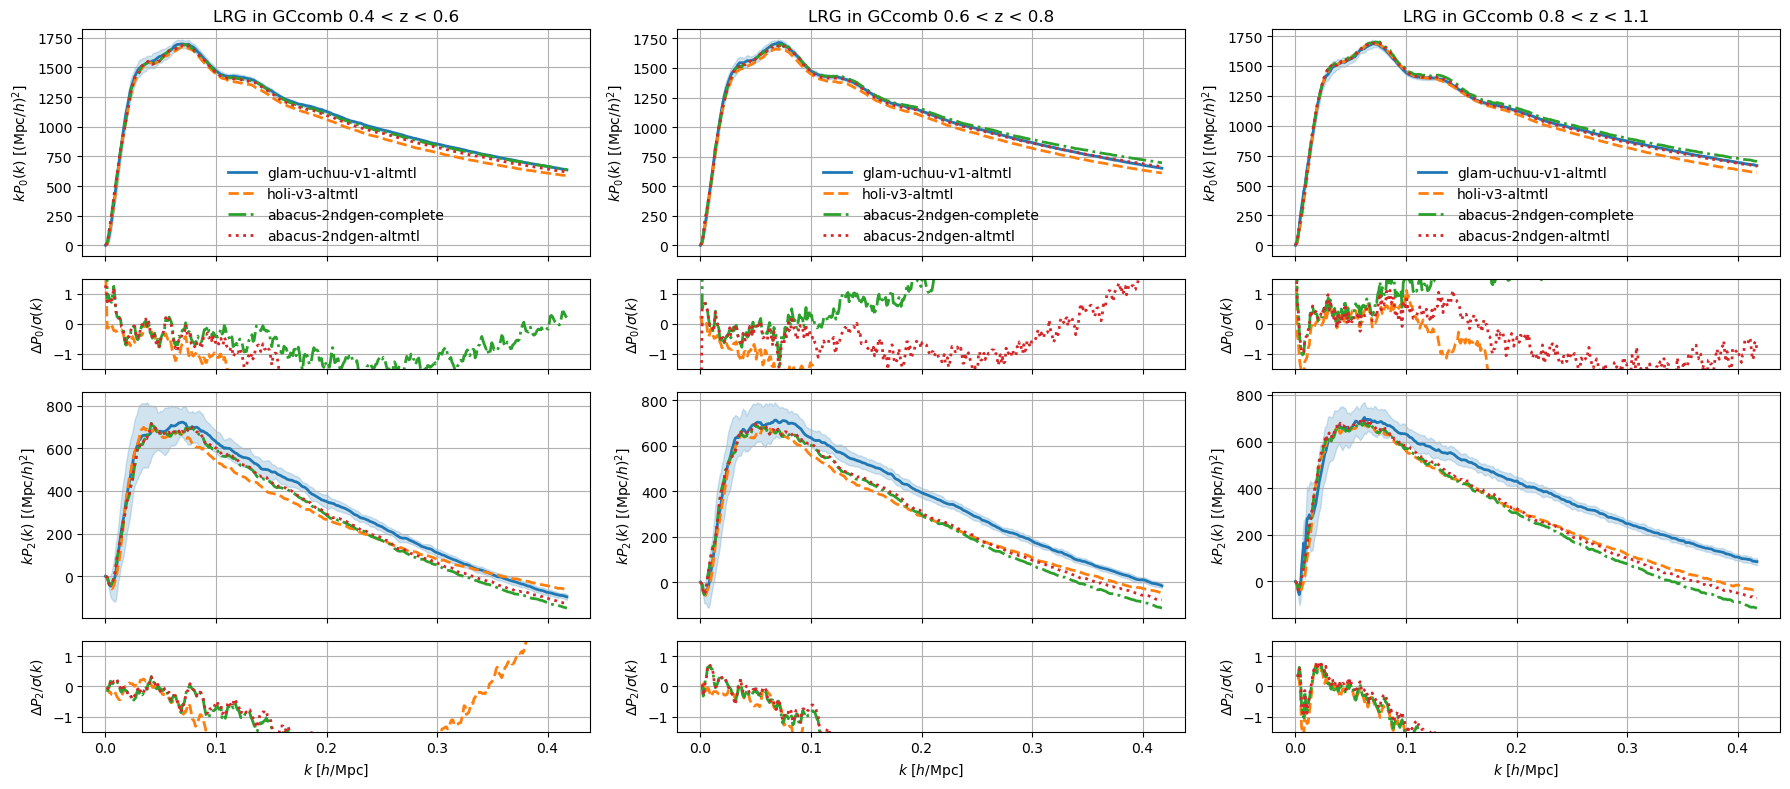

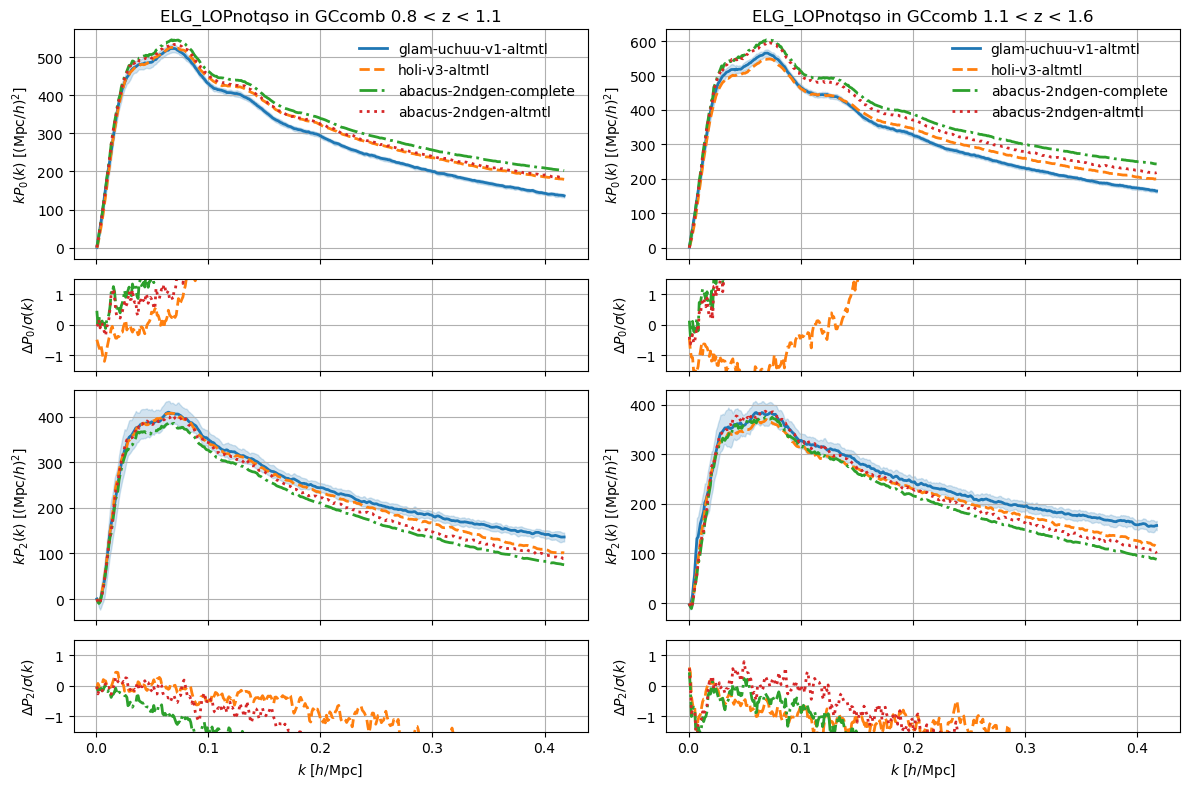

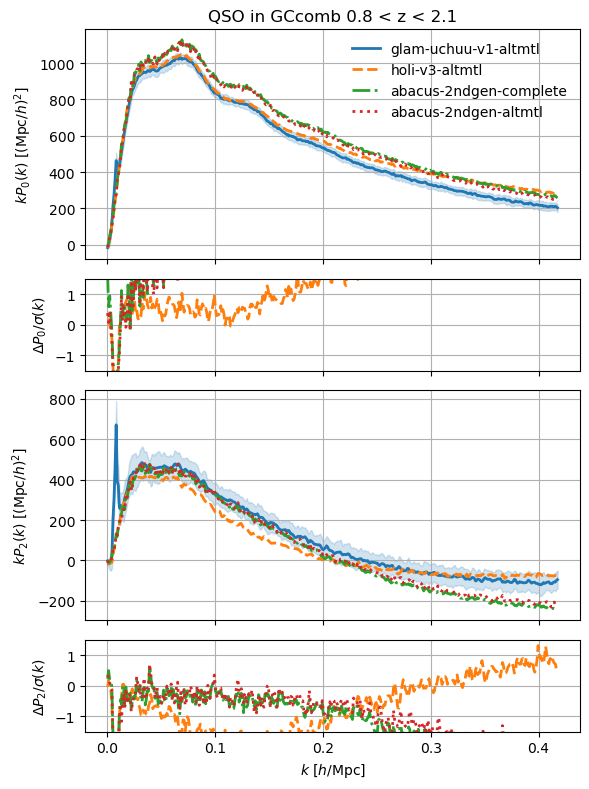

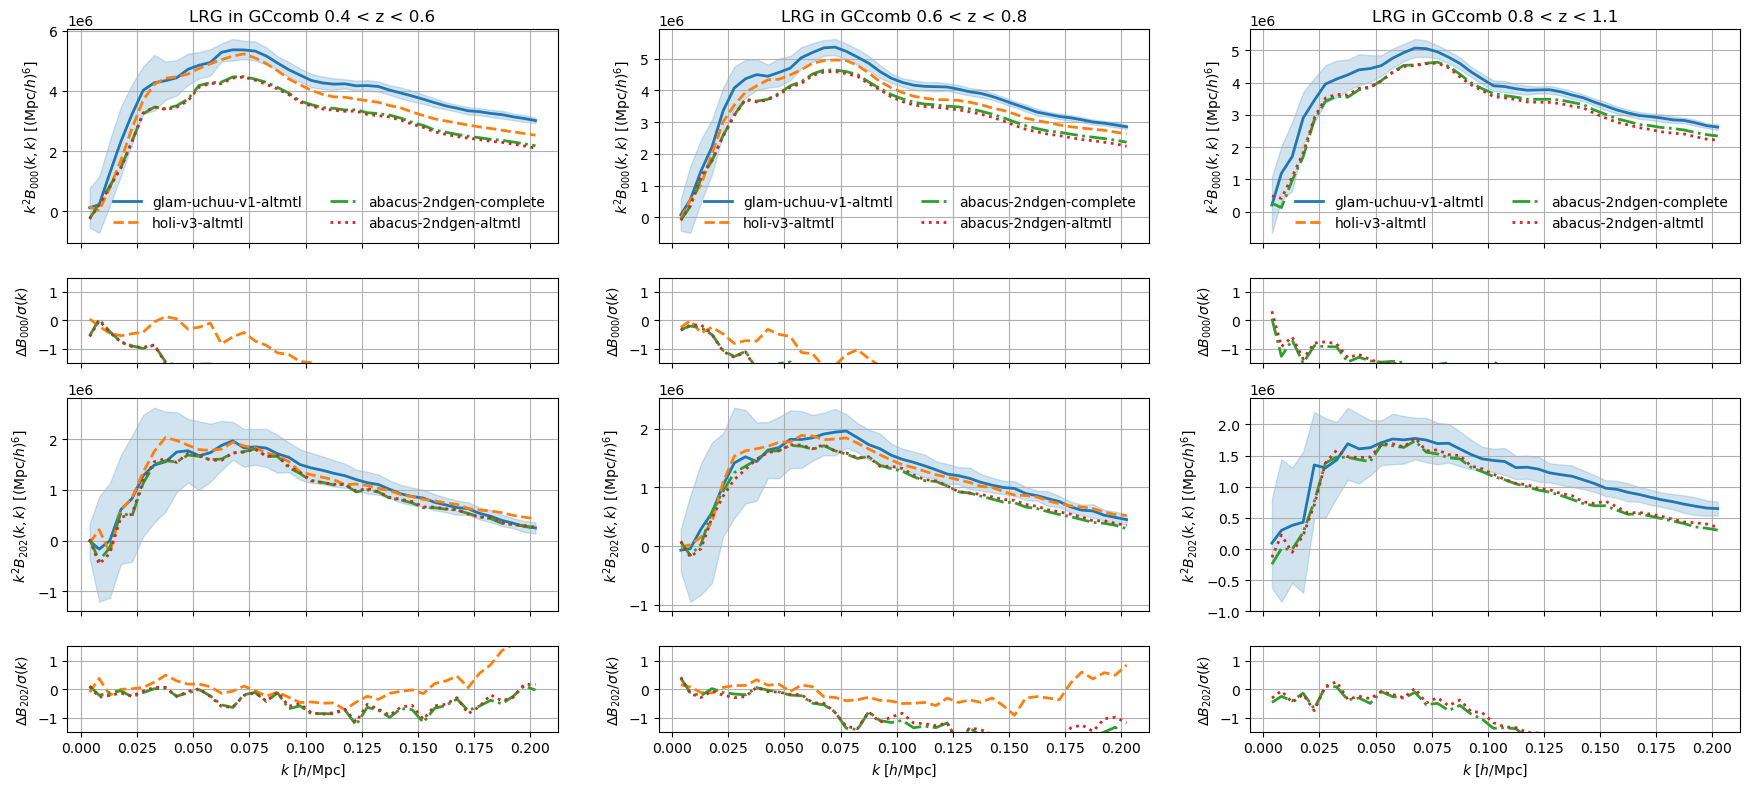

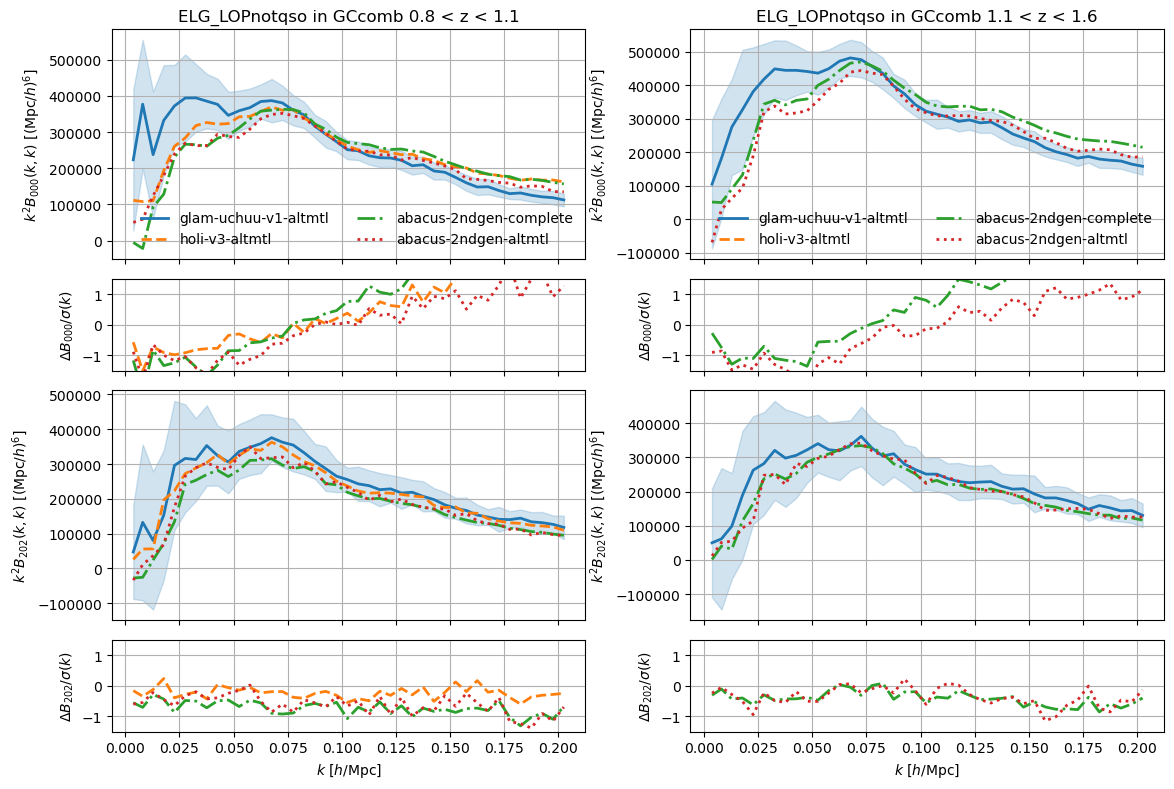

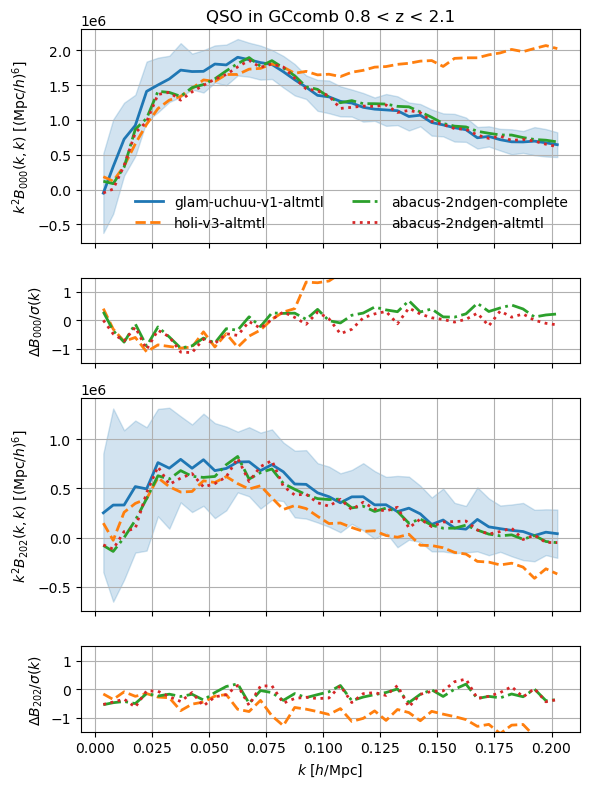

In [6]:
reference = 'glam-uchuu-v1-altmtl'
cases = {'glam-uchuu-v1-altmtl':   {'version': 'glam-uchuu-v1-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},
         'holi-v3-altmtl':   {'version': 'holi-v3-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},
         'abacus-2ndgen-complete':   {'version': 'abacus-2ndgen-complete', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},
         'abacus-2ndgen-altmtl':   {'version': 'abacus-2ndgen-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False}}

scaling='kpk'
# scaling='loglog'
colors = dict(zip(cases, [f'C{i}' for i in range(len(cases))]))
linestyles = dict(zip(cases, ['-', '--','-.',':']))
plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project)

for tracer in tracers:
    zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    nrows  = len(ells4pk) * 2
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4pk)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4pk)})
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4pk)
        plotting_tools.plot_stats('mesh2_spectrum', cases, tracer, zrange, region, **plot_kws)
    plt.tight_layout()
    basename = f'checks_pk_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
    figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()

for tracer in tracers:
    zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    nrows  = len(ells4bk) * 2
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4bk)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4bk)})
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4bk)
        plotting_tools.plot_stats('mesh3_spectrum_sugiyama-diagonal', cases, tracer, zrange, region, **plot_kws)
    plt.tight_layout()
    basename = f'checks_bk_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
    figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()

In [7]:
# check for available measurements
region = 'GCcomb'
for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO']:
    for version in ['holi-v3-altmtl','glam-uchuu-v1-altmtl', 'abacus-2ndgen-complete','abacus-2ndgen-altmtl']:
        if 'ELG' in tracer:
            if 'complete' in version:
                tracer = 'ELG_LOP'
            else:
                tracer = 'ELG_LOPnotqso'
        for zrange in tools.propose_fiducial('zranges',tracer, analysis=analysis):
            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum',
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'mesh2_spectrum',len(fn))
    
            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh3_spectrum', basis='sugiyama-diagonal', 
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'mesh3_spectrum-sugiyama-diagonal',len(fn))
        print()
    print()

LRG holi-v3-altmtl (0.4, 0.6) mesh2_spectrum 57
LRG holi-v3-altmtl (0.4, 0.6) mesh3_spectrum-sugiyama-diagonal 57
LRG holi-v3-altmtl (0.6, 0.8) mesh2_spectrum 57
LRG holi-v3-altmtl (0.6, 0.8) mesh3_spectrum-sugiyama-diagonal 57
LRG holi-v3-altmtl (0.8, 1.1) mesh2_spectrum 57
LRG holi-v3-altmtl (0.8, 1.1) mesh3_spectrum-sugiyama-diagonal 57

LRG glam-uchuu-v1-altmtl (0.4, 0.6) mesh2_spectrum 49
LRG glam-uchuu-v1-altmtl (0.4, 0.6) mesh3_spectrum-sugiyama-diagonal 49
LRG glam-uchuu-v1-altmtl (0.6, 0.8) mesh2_spectrum 49
LRG glam-uchuu-v1-altmtl (0.6, 0.8) mesh3_spectrum-sugiyama-diagonal 49
LRG glam-uchuu-v1-altmtl (0.8, 1.1) mesh2_spectrum 49
LRG glam-uchuu-v1-altmtl (0.8, 1.1) mesh3_spectrum-sugiyama-diagonal 49

LRG abacus-2ndgen-complete (0.4, 0.6) mesh2_spectrum 25
LRG abacus-2ndgen-complete (0.4, 0.6) mesh3_spectrum-sugiyama-diagonal 25
LRG abacus-2ndgen-complete (0.6, 0.8) mesh2_spectrum 25
LRG abacus-2ndgen-complete (0.6, 0.8) mesh3_spectrum-sugiyama-diagonal 25
LRG abacus-2ndgen-

In [8]:
# !ls -l /global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/holi-v3-altmtl/mock0/mesh3_spectrum_sugiyama-diagonal_poles_LRG_z0.8-1.1*

In [9]:
# # region = 'GCcomb'
# region = 'SGC'
# tracer = 'LRG'
# version = 'holi-v3-altmtl'
# versions = {'holi-v3-altmtl':   {'version': 'holi-v3-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False}}

# if 'ELG' in tracer:
#     if 'complete' in version:
#         tracer = 'ELG_LOP'
#     else:
#         tracer = 'ELG_LOPnotqso'
# for zrange in tools.propose_fiducial('zranges',tracer, analysis=analysis)[-1:]:
#     print(zrange)
#     # fig = plt.gcf()
#     fns = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh3_spectrum', basis='sugiyama-diagonal',
#                             version=version, tracer=tracer,
#                             zrange=zrange, region=region, weight='default-FKP', imock='*')
#     # stats = list(map(types.read, fns))
#     # spectrum = types.mean(stats).select(k=slice(0, None, 1))
#     # print(spectrum.get(ells4bk[0]).value().real)
#     for fn in fns:
#         spectrum = types.read(fn)
#         print(fn,spectrum.get(ells4bk[0]).value().real)
#     # spectrum.plot(fig=fig)
#     # plt.legend()
#     # plt.show()

In [10]:
# tracer = 'ELG_LOPnotqso'
# version = 'abacus-2ndgen-complete'
# if 'ELG' in tracer:
#     if 'complete' in version:
#         tracer = 'ELG_LOP'
#     else:
#         tracer = 'ELG_LOPnotqso'
# for zrange in tools.propose_fiducial('zranges',tracer, analysis=analysis):
#     fig = plt.gcf()
#     fns = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum',
#                         version=version, tracer=tracer,
#                         zrange=zrange, region='GCcomb', weight='default-FKP', imock='*')
#     for fn in fns:
#         spectrum = types.read(fn)
#         spectrum.plot(fig=fig)
#     plt.show()